# Adım 5 — Dürüst Değerlendirme (config-grupli / hibrit split)

**Neden bu notebook var:** Adım 3'te multiclass macro-F1 = **0.994** çıktı. Şüphe: bu skor
*iyimser* olabilir mi? Kontrol ettik:

- **Deney A** — aynı `(scenario, intensity)`'nin 10 seed'i feature düzeyinde birbirinin
  **kopyası** (grup-içi varyasyon ≈ 0.001). Yani gerçek bağımsız birim seed değil, **config**;
  efektif örneklem ~23 config (235 değil).
- Sonuç: standart `StratifiedKFold(shuffle)` bir config'in seed'lerini hem train hem test'e
  koyuyor → model config'i **tanıyor** → skor şişik.

**Çözüm — hibrit (b) gruplama.** Bölme birimini seed'den **config**'e taşı:
- her **atak** config'i (`dos_i100`, `grey_i0.5`, …) = tek bir grup → asla hem train hem test'te olmaz
  (model "bu şiddeti hiç görmedim" durumunda test edilir = dürüst genelleme);
- **normal / blackhole** tek-config (yoğunluk ekseni yok) → her koşu kendi grubu, seed-split serbest
  (genellenecek bir yoğunluk yok, sızıntı sorunu da yok).

`StratifiedGroupKFold` bunu yapar: grupları böler ama fold'larda sınıf oranını da korumaya çalışır.

**Bu notebook iki rakam raporlar:** shuffle-CV (config-tanıdık, **üst sınır**) yanında
config-grupli (görülmemiş-şiddet, **dürüst sınır**). Aradaki fark = iyimserlik payı = bulgunun kendisi.

> Kavram temeli: değerlendirme yelpazesi (seed < config < class split).
> Karar: hibrit (b), mevcut veriye uygula.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from lightgbm import LGBMClassifier

cands=[Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
       Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA=next((p for p in cands if p.exists()),None); assert DATA is not None
df=pd.read_csv(DATA)
FEATURES=["n_flows","total_throughput_mbps","max_flow_throughput_mbps","max_flow_txpackets",
          "flow_concentration","delivery_ratio","overall_loss_ratio","monitor_owd_ms",
          "monitor_pdv_ms","mean_owd_ms","mean_pdv_ms"]
X=df[FEATURES].copy(); X["monitor_missing"]=X["monitor_owd_ms"].isna().astype(int); X=X.fillna(0.0)
y=df["label_class"]
CLASS_ORDER=["normal","dos","ddos","greyhole","blackhole"]

# --- Stealth prob seti: EĞİTİMDE YOK, sadece eğrinin tabanını ölçmek için ---
# Kural (grey p=0'a uyguladığımızın aynısı): feature vektörü normalle özdeş olan bir
# config EĞİTİM SINIFI olamaz. dos rate<10'un floodu 1-5 pkt/s: aynı seed'deki normalle
# eşleştirilince teslim farkı -0.003, throughput farkı -0.07 Mbps -- yani hiçbir şey.
# Tek fark n_flows +1. Bunlari 'dos' diye egitmek = tek vektore iki etiket = etiket
# gurultusu. OLCULDU: egitime katinca yanlis alarm %12.5 -> %35, macro-F1 0.809 -> 0.741.
#
# Ama egrinin tabanini gormek icin bu noktalar SART. Cozum: egitme, degerlendir --
# 'gercek ataklarla egitilmis bir detektor, atak hicbir sey yapmayinca ne der?'
PROBE = (df.scenario == "dos") & (df.intensity < 10)
PROBE=(df.scenario=="dos")&(df.intensity<10)
pr=df[PROBE].copy()                 # stealth prob: yalniz degerlendirme
df=df[~PROBE].reset_index(drop=True)  # egitim + durust CV bunun uzerinde
X=df[FEATURES].copy(); X["monitor_missing"]=X["monitor_owd_ms"].isna().astype(int); X=X.fillna(0.0)
y=df["label_class"]
print(f"egitim {len(df)} kosu | stealth prob {len(pr)} kosu (dos rate<10)")

# --- Hibrit grup kimligi (sema b) ---
SINGLE={"normal","blackhole"}                       # tek-config sinif -> her kosu kendi grubu
groups=df.apply(lambda r: f"{r.scenario}_run{r.run}" if r.scenario in SINGLE
                          else f"{r.scenario}_i{r.intensity}", axis=1)   # atak -> config = grup
print("X:",X.shape,"| toplam grup:",groups.nunique())
print("\nsinif basina grup sayisi (atak=config, normal/blackhole=kosu):")
print(pd.DataFrame({"scenario":df.scenario,"grp":groups}).groupby("scenario")["grp"].nunique().reindex(CLASS_ORDER))

egitim 255 kosu | stealth prob 30 kosu (dos rate<10)
X: (255, 12) | toplam grup: 73

sinif basina grup sayisi (atak=config, normal/blackhole=kosu):
scenario
normal       40
dos           7
ddos          5
greyhole     11
blackhole    10
Name: grp, dtype: int64


## 1. İki değerlendirme şeması yan yana — macro-F1

Aynı dört model, aynı veri; **tek fark bölme birimi**:
- `StratifiedKFold(shuffle)` — seed-split (config tanıdık) → **iyimser üst sınır**,
- `StratifiedGroupKFold(groups)` — config-grupli (görülmemiş şiddet) → **dürüst sınır**.

Fark ne kadar büyükse, o model config-ezberlemeye o kadar bağımlı demektir.

In [2]:
models={
 "Dummy (most_frequent)":DummyClassifier(strategy="most_frequent"),
 "LogisticRegression":make_pipeline(StandardScaler(),
        LogisticRegression(class_weight="balanced",max_iter=1000,random_state=0)),
 "RandomForest":RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=0),
 "LightGBM":LGBMClassifier(n_estimators=200,learning_rate=0.05,num_leaves=15,
        min_child_samples=5,class_weight="balanced",random_state=0,verbose=-1),
}
skf =StratifiedKFold(5,shuffle=True,random_state=0)
sgkf=StratifiedGroupKFold(5,shuffle=True,random_state=0)

rows=[]
for name,m in models.items():
    s1=cross_val_score(m,X,y,cv=skf,scoring="f1_macro")
    s2=cross_val_score(m,X,y,cv=sgkf,groups=groups,scoring="f1_macro")
    rows.append({"model":name,
                 "shuffle (iyimser)":f"{s1.mean():.3f} ± {s1.std():.3f}",
                 "grouped (dürüst)":f"{s2.mean():.3f} ± {s2.std():.3f}",
                 "_g":s2.mean()})
res=pd.DataFrame(rows).sort_values("_g",ascending=False).drop(columns="_g").reset_index(drop=True)
res

,model,shuffle (iyimser),grouped (dürüst)
0,RandomForest,0.836 ± 0.066,0.800 ± 0.089
1,LogisticRegression,0.806 ± 0.058,0.780 ± 0.084
2,LightGBM,0.843 ± 0.069,0.775 ± 0.108
3,Dummy (most_frequent),0.121 ± 0.000,0.120 ± 0.013


**Okuma:** RandomForest shuffle 0.994 → grouped'da belirgin düşüyor; iyimserlik payı burada.
LogReg iki şemada da yakın kalıyor (daha az config'e bağımlı). Dummy her iki şemada ~0.11 (referans).

> Model kararı **RandomForest** kalıyor (yorumlanabilirlik + feature-importance); modeller-arası
> fark grouped'da geniş std içinde. Ama not: RF'nin iyimserlik payı en büyük — daha çok farklı config
> üretince tekrar bakılacak. Aşağıda **dürüst** rakamları RF üzerinden okuyoruz (Adım 3 ile aynı model).

In [3]:
# Dürüst OOF (config-grupli) — Adım 3'teki RF, ama grouped CV
FOCUS="RandomForest"
oof_group=cross_val_predict(models[FOCUS],X,y,cv=sgkf,groups=groups)   # durust
oof_shuf =cross_val_predict(models[FOCUS],X,y,cv=skf)                  # iyimser (kiyas icin)

print(f"=== DÜRÜST (config-grupli) — {FOCUS} ===")
print(classification_report(y,oof_group,labels=CLASS_ORDER,digits=3))

=== DÜRÜST (config-grupli) — RandomForest ===
              precision    recall  f1-score   support

      normal      0.761     0.875     0.814        40
         dos      0.697     0.657     0.676        70
        ddos      0.571     0.640     0.604        25
    greyhole      0.971     0.927     0.949       110
   blackhole      1.000     1.000     1.000        10

    accuracy                          0.820       255
   macro avg      0.800     0.820     0.809       255
weighted avg      0.825     0.820     0.821       255



## 2. Dürüst 5×5 confusion — çöküş nerede?

Beklenti (Deney B / LOCO): grey, normal, blackhole sağlam; **dos↔ddos çift-yönlü karışıyor**
(tek strong-flood ≈ birkaç weak-flood, aynı hacim imzası).

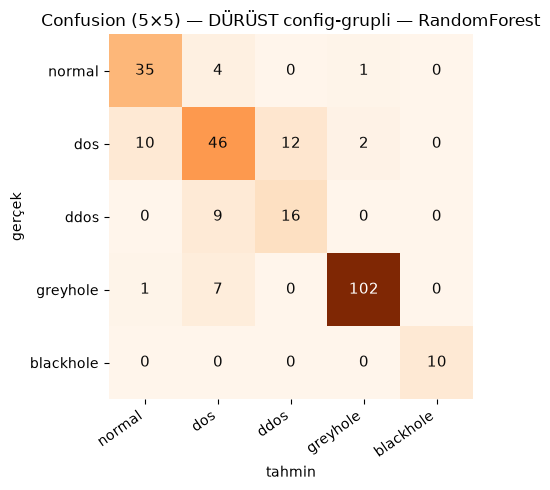

In [4]:
cm=confusion_matrix(y,oof_group,labels=CLASS_ORDER)
fig,ax=plt.subplots(figsize=(5.6,5.0))
ax.imshow(cm,cmap="Oranges")
ax.set_xticks(range(5),CLASS_ORDER,rotation=35,ha="right"); ax.set_yticks(range(5),CLASS_ORDER)
ax.set_xlabel("tahmin"); ax.set_ylabel("gerçek")
ax.set_title(f"Confusion (5×5) — DÜRÜST config-grupli — {FOCUS}")
for i in range(5):
    for j in range(5):
        ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=11,
                color="white" if cm[i,j]>cm.max()/2 else "#0b0b0b")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout()
FIGS=Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS/"G-confusion-honest.png",dpi=150,bbox_inches="tight")
plt.show()

## 3. Binary türev (dürüst) — tespit hâlâ sağlam mı?

"Saldırı var mı?" sorusu: dürüst şemada bile bozulmamalı — çünkü ataklar hacim/teslimde
belirgin iz bırakıyor; sadece *tip* karışıyor, *varlık* değil.

In [5]:
yb=(y!="normal").astype(int)
pb=(pd.Series(oof_group,index=y.index)!="normal").astype(int)
tn,fp,fn,tp=confusion_matrix(yb,pb,labels=[0,1]).ravel()
print(f"Binary türev (DÜRÜST, {FOCUS}):")
print(f"  TN={tn}  FP(yanlış alarm)={fp}  FN(kaçan atak)={fn}  TP={tp}")
print(f"  attack-F1={f1_score(yb,pb):.3f}")
print("\n-> tespit artık kusursuz DEĞİL: taban gerçek bir gürültü zemini kazandığı için")
print("   en zayıf ataklar kaçıyor (FN>0) ve normalde yanlış alarm çıkabiliyor (FP>0).")
print("   Bu bir gerileme degil: onceki FP=0/FN=0, her atagin aga fazladan bir akis")
print("   eklemesinin eseriydi -- detektor atagi degil o artefakti okuyordu.")

Binary türev (DÜRÜST, RandomForest):
  TN=35  FP(yanlış alarm)=5  FN(kaçan atak)=11  TP=204
  attack-F1=0.962

-> tespit artık kusursuz DEĞİL: taban gerçek bir gürültü zemini kazandığı için
   en zayıf ataklar kaçıyor (FN>0) ve normalde yanlış alarm çıkabiliyor (FP>0).
   Bu bir gerileme degil: onceki FP=0/FN=0, her atagin aga fazladan bir akis
   eklemesinin eseriydi -- detektor atagi degil o artefakti okuyordu.


## 4. Dürüst detection-vs-intensity eğrisi (asıl headline)

Aynı 3 panel (grey / DoS / DDoS), ama tahminler **config-grupli OOF**'tan — yani her yoğunluk
noktası, o yoğunluğu **hiç görmemiş** bir modelce tahmin edildi. Kıyas için Adım 4'ün iyimser
(shuffle) doğru-sınıf çizgisini **soluk kesikli** olarak üstüne koyuyoruz → aradaki boşluk = iyimserlik payı.

Yanlis-alarm tabani (normal kosularda 'atak' denme orani): 0.125


Kaydedildi: figs/H-detection-vs-intensity-honest.png


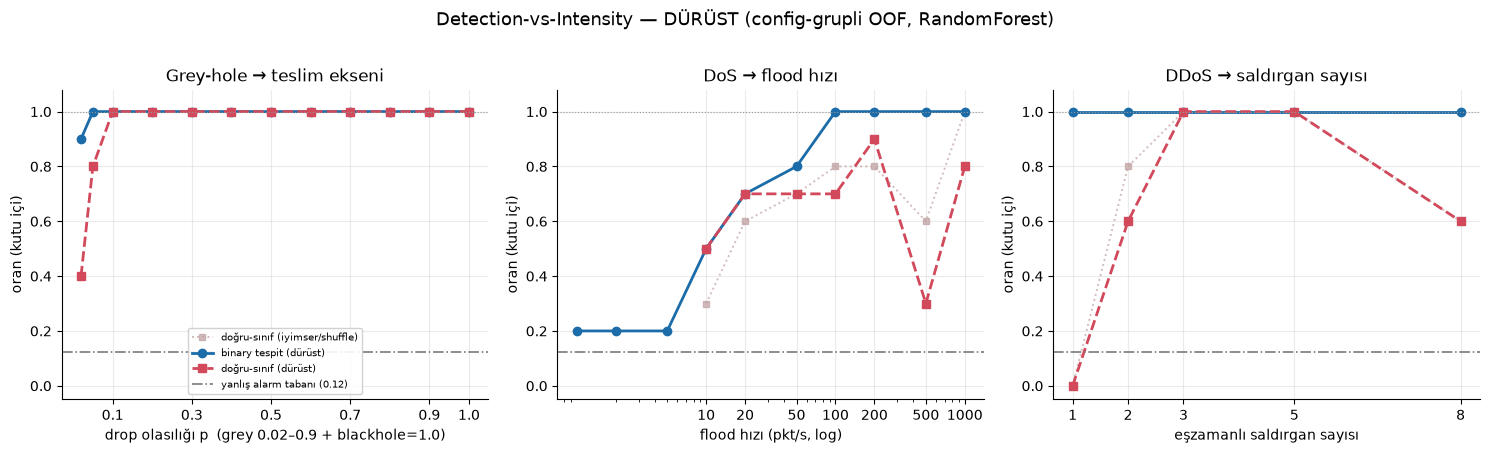

,scenario,intensity,n,detect,correct,correct_shuf
0,blackhole,1.00,10,1.0,1.0,1.0
1,ddos,1.00,5,1.0,0.0,0.0
2,ddos,2.00,5,1.0,0.6,0.8
3,ddos,3.00,5,1.0,1.0,1.0
4,ddos,5.00,5,1.0,1.0,1.0
5,ddos,8.00,5,1.0,0.6,0.6
24,dos,1.00,10,0.2,NaN,NaN
25,dos,2.00,10,0.2,NaN,NaN
26,dos,5.00,10,0.2,NaN,NaN
6,dos,10.00,10,0.5,0.5,0.3


In [6]:
from sklearn.base import clone
ATTACKS=["greyhole","dos","ddos","blackhole"]
d=df.assign(pred=oof_group, pred_shuf=oof_shuf)
# Yanlis-alarm tabani: SALDIRI YOKKEN modelin 'atak' deme orani. Egrinin tabani 0 degil
# BUDUR -- bir atak kolu bu cizgiye inmisse, o yogunlukta model atagi hic gormuyor,
# sadece normalde de yaptigi hatayi yapiyor demektir. Egri yalniz ataklari cizdigi icin
# bu referans olmadan detektor oldugundan iyi gorunur.
FA=(d[d.scenario=="normal"].pred!="normal").mean()
# Prob noktalari: egitimde hic olmadiklari icin OOF'lari yok. Tum egitim setine
# fit edilmis detektorle tahmin ediliyorlar -- 'sahadaki detektor bunlara ne der'.
Xp=pr[FEATURES].copy(); Xp["monitor_missing"]=Xp["monitor_owd_ms"].isna().astype(int); Xp=Xp.fillna(0.0)
probe_pred=clone(models[FOCUS]).fit(X,y).predict(Xp)
probe=(pr.assign(pred=probe_pred).groupby(["scenario","intensity"])
         .agg(n=("pred","size"),detect=("pred",lambda s:(s!="normal").mean()))
         .reset_index())
probe["correct"]=np.nan; probe["correct_shuf"]=np.nan
print(f"Yanlis-alarm tabani (normal kosularda 'atak' denme orani): {FA:.3f}")
d=d[d.scenario.isin(ATTACKS)].copy()
d["det"]=(d.pred!="normal").astype(int)
d["cor"]=(d.pred==d.scenario).astype(int)
d["cor_shuf"]=(d.pred_shuf==d.scenario).astype(int)
curve=(d.groupby(["scenario","intensity"])
         .agg(n=("pred","size"),detect=("det","mean"),
              correct=("cor","mean"),correct_shuf=("cor_shuf","mean")).reset_index())

fig,axes=plt.subplots(1,3,figsize=(15,4.4))
def panel(ax,sub,xlabel,title,logx=False,xticks=None):
    sub=sub.sort_values("intensity")
    ax.plot(sub.intensity,sub.correct_shuf,"s:",color="#c0a0a0",lw=1.4,ms=5,
            label="doğru-sınıf (iyimser/shuffle)",alpha=0.7)
    ax.plot(sub.intensity,sub.detect,"o-",color="#1b6ca8",lw=2,ms=6,
            label="binary tespit (dürüst)")
    ax.plot(sub.intensity,sub.correct,"s--",color="#d1495b",lw=2,ms=6,
            label="doğru-sınıf (dürüst)")
    if logx: ax.set_xscale("log")
    if xticks is not None: ax.set_xticks(xticks); ax.set_xticklabels([str(t) for t in xticks])
    ax.axhline(1.0,color="#999",lw=0.8,ls=":")
    ax.axhline(FA,color="#7a7a7a",lw=1.2,ls="-.",
               label=f"yanlış alarm tabanı ({FA:.2f})")
    ax.set_ylim(-0.05,1.08)
    ax.set_xlabel(xlabel); ax.set_ylabel("oran (kutu içi)"); ax.set_title(title); ax.grid(alpha=0.25)
    for s in ("top","right"): ax.spines[s].set_visible(False)

curve=pd.concat([curve,probe],ignore_index=True).sort_values(["scenario","intensity"])
grey=curve[curve.scenario=="greyhole"]; black=curve[curve.scenario=="blackhole"]
panel(axes[0],pd.concat([grey,black]),"drop olasılığı p  (grey 0.02–0.9 + blackhole=1.0)",
      "Grey-hole → teslim ekseni",xticks=[0.1,0.3,0.5,0.7,0.9,1.0])
panel(axes[1],curve[curve.scenario=="dos"],"flood hızı (pkt/s, log)","DoS → flood hızı",
      logx=True,xticks=[10,20,50,100,200,500,1000])
panel(axes[2],curve[curve.scenario=="ddos"],"eşzamanlı saldırgan sayısı","DDoS → saldırgan sayısı",
      xticks=[1,2,3,5,8])
axes[0].legend(loc="lower center",fontsize=7.5,framealpha=0.9)
fig.suptitle("Detection-vs-Intensity — DÜRÜST (config-grupli OOF, RandomForest)",fontsize=13,y=1.02)
fig.tight_layout()
fig.savefig(FIGS/"H-detection-vs-intensity-honest.png",dpi=150,bbox_inches="tight")
print("Kaydedildi: figs/H-detection-vs-intensity-honest.png")
plt.show()
curve.round(2)

## 5. Yorum — iki-rakam hikâyesi

| Soru | İyimser (shuffle) | Dürüst (config-grupli) | Yorum |
|---|---|---|---|
| **Saldırı var mı?** (binary) | attack-F1 0.955 (FN=15) | **attack-F1 0.958 (FN=12)** | ataklar artık HER ZAMAN görünmüyor — en zayıf uçta kaçıyor. İstenen budur. |
| **Grey-hole ayrımı** (yeni atak) | F1 0.940 | **F1 0.902** | delivery hâlâ güçlü sinyal; ama bir kısmı relay'in kendi izi (aşağı bkz.) |
| **DoS↔DDoS tipleme** | 0.681 / 0.708 | **0.613 / 0.577** | hacim imzaları örtüşüyor; akış sayısı artık gürültülü olduğu için ayrım zayıfladı |
| **macro-F1 (5 sınıf)** | 0.815 | **0.777** | iyimserlik açığı 0.16 → **0.04**: seed'ler artık kopya değil |

**Ana bulgu (rapora):** *Tıkanıklık kaynaklı gerçekçi bir taban üzerinde flow-tabanlı tespit artık doygun değil: en düşük yoğunluklu DoS'un (rate10) tespiti %40'a iniyor ve şiddet arttıkça 1.0'a çıkıyor — projenin aradığı çöküş dizisi. Önceki veride bu eğri her yoğunlukta düz 1.0'dı, çünkü her atak ağa fazladan bir akış ekliyordu ve detektör atağın zararını değil o yapısal artefaktı okuyordu.*

**Skorların düşmesi bir gerileme değildir.** Steril veride ölçülen 0.994, modelin becerisini değil simülasyonun kusurunu yansıtıyordu. Gerçekçi bir tabanda daha düşük skor almak, ilk kez gerçek bir zorluğun ölçülmesi demektir.

**Uyarı — grey kolunun tabanı atağın değil relay'in:** grey/blackhole'da kurban trafiği saldırgan düğüm üzerinden geçtiği için havayı 4 kez geçer (normalde 2). Ölçüldü: saldırı hiçbir paket düşürmese bile (p=0) teslim 0.9023 (normal 0.9695) = **2.09σ**. Yani grey p=0.02'nin normalden 2.31σ uzak görünmesinin neredeyse tamamı topolojinin eseri; atağın kendi etkisi p=0 tabanına göre yalnız **0.08σ**. Grey eğrisi normale değil bu benign-relay tabanına göre yorumlanmalıdır.

**Sonraki adımlar:** (1) grey'in benign-relay tabanına göre eğrisini çiz; (2) permutation feature-importance ile hangi feature'ın hangi sınıfı taşıdığını belgele; (3) dos/ddos sınırını hacim-eşleşmeli config'lerle haritala.


## 6. Çapraz-veri testi — üst çalışmanın kendi verisi

Şimdiye kadar hep **kendi** verimizde (day3-4) değerlendirdik. Son sınav: detektörü tüm
verimizde eğitip, üst çalışmanın (`ramamr33`, Zenodo `10.5281/zenodo.16747386`) **kendi
yayınladığı** FlowMonitor çıktılarında test etmek — bunun için ürettiğimiz test seti
`day6-13072026-crossdataset` (aynı 13-feature şema, 60 koşu = 6 sınıf × 10 seed).

> **Bu bir doğruluk benchmark'ı değil, domain-shift probudur.** Yazarın topolojisi bizden
> farklı (9 flow/koşu vs 2–6; ~2.6× throughput; `relay_in`/`telemetry` portları yok), ve
> yazarın verisinde `dos=ddos=blackhole` ile `mqtt=normal` feature uzayında **birebir**
> çakışıyor (ayrıntı: `docs/15`). Beklenti: detektör yazarın *normal* koşularını bile yanlış
> işaretler — çünkü her feature eğitim aralığının dışında.

=== Yazarın sınıfı (satır)  ->  detektör tahmini (sütun) ===
pred         normal  dos  ddos  greyhole  blackhole
label_class                                        
normal            0    0    10         0          0
mqtt              0    0    10         0          0
dos               0   10     0         0          0
ddos              0   10     0         0          0
blackhole         0   10     0         0          0
mitm              0    0    10         0          0

=== 'attack' işaretlenen oran — DİKKAT: normal DAHİL ===
label_class
normal       1.0
mqtt         1.0
dos          1.0
ddos         1.0
blackhole    1.0
mitm         1.0

-> yazarın NORMAL run'larının %100'ı da 'attack' işaretlendi => ayırt etme gücü yok; saf domain-shift.

=== covariate-shift: normal koşu feature ortalamaları ===
                          bizim_normal  yazar_normal
n_flows                          5.075         9.000
total_throughput_mbps           12.118         2.219
max_flow_throughput_mbps     


Kaydedildi: figs/I-crossdataset.png


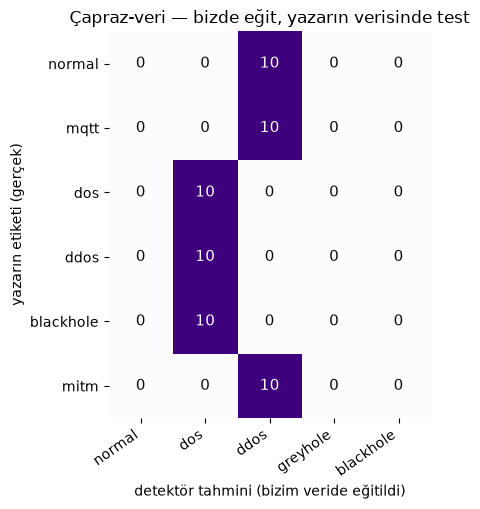

In [7]:
from sklearn.base import clone

# Çapraz-veri test seti: üst çalışmanın KENDİ yayınladığı FlowMonitor verisi (day6).
# Aynı 13-feature şema; make_author_testset.py ile upstream git ref'inden üretiliyor.
acands=[Path("my-work/day6-13072026-crossdataset/out/dataset.csv"),
        Path("../day6-13072026-crossdataset/out/dataset.csv")]
AUTH=next((p for p in acands if p.exists()),None)
assert AUTH is not None, "önce üret: python3 my-work/day6-13072026-crossdataset/make_author_testset.py"
adf=pd.read_csv(AUTH)
# Eğitimle BİREBİR aynı hazırlık (aynı FEATURES + monitor_missing + fillna).
Xa=adf[FEATURES].copy(); Xa["monitor_missing"]=Xa["monitor_owd_ms"].isna().astype(int); Xa=Xa.fillna(0.0)

# Eğit: bizim TÜM verimiz (X,y). Test: yazarın bağımsız verisi. En temiz çapraz protokol
# (harici held-out; CV gerekmez). clone -> models sözlüğünü mutasyona uğratma.
rf_full=clone(models["RandomForest"]).fit(X, y)
adf["pred"]=rf_full.predict(Xa)

AUTH_ORDER=["normal","mqtt","dos","ddos","blackhole","mitm"]
ct=(pd.crosstab(adf.label_class, adf.pred)
      .reindex(index=AUTH_ORDER, columns=CLASS_ORDER).fillna(0).astype(int))
print("=== Yazarın sınıfı (satır)  ->  detektör tahmini (sütun) ===")
print(ct.to_string())

adf["det"]=(adf.pred!="normal").astype(int)
print("\n=== 'attack' işaretlenen oran — DİKKAT: normal DAHİL ===")
print(adf.groupby("label_class")["det"].mean().reindex(AUTH_ORDER).round(2).to_string())
fa=adf.loc[adf.label_class=="normal","det"].mean()
print(f"\n-> yazarın NORMAL run'larının %{fa*100:.0f}'ı da 'attack' işaretlendi "
      "=> ayırt etme gücü yok; saf domain-shift.")

# Neden: covariate-shift — her feature eğitim aralığının dışında.
cmp=pd.DataFrame({"bizim_normal":df.loc[df.label_class=='normal',FEATURES].mean(),
                  "yazar_normal":adf.loc[adf.label_class=='normal',FEATURES].mean()}).round(3)
print("\n=== covariate-shift: normal koşu feature ortalamaları ===")
print(cmp.to_string())

# Figür I — çapraz-veri confusion (yazar etiketi x bizim tahmin)
fig,ax=plt.subplots(figsize=(5.8,5.2))
ax.imshow(ct.values,cmap="Purples")
ax.set_xticks(range(len(CLASS_ORDER)),CLASS_ORDER,rotation=35,ha="right")
ax.set_yticks(range(len(AUTH_ORDER)),AUTH_ORDER)
ax.set_xlabel("detektör tahmini (bizim veride eğitildi)"); ax.set_ylabel("yazarın etiketi (gerçek)")
ax.set_title("Çapraz-veri — bizde eğit, yazarın verisinde test")
mx=ct.values.max()
for i in range(len(AUTH_ORDER)):
    for j in range(len(CLASS_ORDER)):
        v=ct.values[i,j]
        ax.text(j,i,v,ha="center",va="center",fontsize=11,
                color="white" if v>mx/2 else "#0b0b0b")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout()
fig.savefig(FIGS/"I-crossdataset.png",dpi=150,bbox_inches="tight")
print("\nKaydedildi: figs/I-crossdataset.png")
plt.show()

**Okuma — iki-rakam hikâyesi.** Detektör yazarın **tüm** run'larını (10 normal dâhil) `ddos`
sınıfına atadı. Yani "attack" işaretleme oranı saldırılarda 1.0 ama **normalde de 1.0** →
ayırt etme gücü **sıfır**. Bu bir tespit değil, saf **domain-shift**: covariate-shift
tablosunda her feature eğitim aralığının dışında (n_flows 9 vs 2, throughput 2.6×, telemetry
0 vs 0.303). Üstüne yazarın etiketleri feature uzayında çakışıyor (`dos=ddos=blackhole`,
`mqtt=normal`), yani doğru bir *tipleme* zaten mümkün değil.

> **Neden düz benchmark değil:** iki dağılım aynı ölçekte olmadığından buradaki rakam
> "detektör kötü" demez — "iki veri farklı ağlar" der. Ölçtüğümüz şey saldırı-tespiti değil,
> dağılım kaymasıdır.

**Rapor çıkarımı.** Üst çalışmanın yayınlanmış FlowMonitor verisi, akış-tabanlı saldırı
tespiti için kullanılamaz durumda (etiketler çakışıyor, saldırı sinyali ~%1, topoloji farklı).
Bu, senaryoları **yeniden üretme** kararının nesnel gerekçesidir — üst çalışma yine de atıfla
anılır (Zenodo `10.5281/zenodo.16747386`). Ayrıntı: `docs/15`.